In [112]:
# Library Imports

from decimal import DivisionByZero
import pandas as pd
# pd.set_option('display.max_columns', None)
import numpy as np
from datetime import datetime,date
import os
import glob
import re
import matplotlib.pyplot as plt
import cv2 as cv
from functools import reduce
from sklearn.cluster import DBSCAN
from  converters import hgs_to_pixel_converter as hgs
from converters import pixel_to_hgs_converter as pix
from sklearn.metrics.pairwise import euclidean_distances
import geopandas as gpd
import shapely.geometry as geometry
from ast import literal_eval
from scipy.spatial import distance
import streamlit as st
from PIL import Image
from io import BytesIO
import base64
from mpl_toolkits.axes_grid1 import make_axes_locatable
from post_hoc_analysis import superimpose_original,normalize_image,superimpose_image,superimpose_circular_edge_npy,annotate_points



In [113]:

def retrieve_npy(filename,media='media',root=None):
    if root is not None:
        folder = os.path.join(media, root,  *filename.split(' ')[0].split('-'))
        save_path = os.path.join(folder, f"{filename.replace('-','_').replace(' ','_').replace(':','_')}.npy")
        return save_path

def retrieve_ar(request_date,media='media',plage=False,events=False):
    # Ensure request_date is a datetime object
    if not isinstance(request_date, pd.Timestamp):
        try:
            request_date = pd.to_datetime(request_date)
        except Exception as e:
            print(f"Error converting request_date to datetime: {e}")
            return None
    # Filter ars DataFrame for the specific request_date
    ars_select = ars[pd.to_datetime(ars['ar_date']).dt.strftime('%Y-%m-%d') == request_date.date().strftime('%Y-%m-%d')]
    if plage:
        ars_select = ars_select[ars_select['greenwich'] != 'Plage']
    if events:
        ars_select = ars_select[ars_select['Count'].fillna(0) > 0]
    ar_names = ars_select.noaa_ar_no.to_list()
    ar_lat =  ars_select.latitude.to_list()
    ar_lon =  ars_select.longitude.to_list()    
    return ar_names,ar_lat,ar_lon
    
def retrieve_img(filename,media='media',extension='svg',root=None):
    if root is not None:
        folder = os.path.join(media, root,  *filename.split(' ')[0].split('-'))
        save_path = os.path.join(folder, f"{filename.replace('-','_').replace(' ','_').replace(':','_')}.{extension}")
        return save_path

def convert_to_pix(lon, lat):
    """
    convert hgs to pixel coordinates
    :param lon: Heliographic Stonyhurst longitude
    :param lat: Heliographic Stonyhurst latitude
    :return: pixel coordinates
    """

    return hgs.convert_hgs_to_pix(lon, lat)

# pix_list = [convert_to_pix(x[0],x[1]) for x in zip(dff.rest_lon.values[0],dff.rest_lat.values[0])]
# pix_list = list(zip(dff.rest_fl.values[0],pix_list))

def get_hulls(file_path, original_file_path, lower_threshold=10,upper_threshold=30,min_samples=2,distance_threshold=1,numpy=True): #should use uploaded image instead of file_path
    """
    Get the convex hulls of the attribution map
    :param file_path: Path to the attribution map
    :return: List of convex hulls
    """
    def preprocess_image(img):
        # If the image has a single color channel, squeeze it
        if img.ndim == 3 and img.shape[2] == 1:
            img = img.squeeze(-1)

        # Normalize or scale the image values if they aren't already in the 0-255 range
        if img.max() <= 1:
            img = (img - img.min()) / (img.max() - img.min())
            img  = (img * 255).astype(np.uint8)
        return img

    def trim_image(image, border_width=2):
        """Trim the edges of an image by setting the border pixels to black
            because the edges are introducing noise.
            :param image: The image to trim
            :param border_width: The width of the border to trim
            :return: The trimmed image
        """

        # Set the edges of the image to black pixels
        image[:border_width, :] = 255  # Top border
        image[-border_width:, :] = 255  # Bottom border
        image[:, :border_width] = 255  # Left border
        image[:, -border_width:] = 255  # Right border

        return image

    def remove_circular_mask(original_image, background_image):
        # Ensure the images are in the correct format (8-bit grayscale)
        if original_image.dtype != np.uint8:
            original_image = (original_image / original_image.max() * 255).astype(np.uint8)
        if background_image.dtype != np.uint8:
            background_image = (background_image / background_image.max() * 255).astype(np.uint8)
        
        # Find the largest contour in the original image
        _, thresholded_image = cv.threshold(original_image, 1, 255, cv.THRESH_BINARY)
        contours, _ = cv.findContours(thresholded_image, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        largest_contour = max(contours, key=cv.contourArea)
        
        # Resize the background image to match the original image's dimensions
        resized_background_image = cv.resize(background_image, (original_image.shape[1], original_image.shape[0]))
        
        # Create a mask for the largest contour
        mask = np.zeros_like(resized_background_image, dtype=np.uint8)
        cv.drawContours(mask, [largest_contour], -1, (255), thickness=cv.FILLED)
        
        # Superimpose the contour on the resized background image
        superimposed_image = cv.bitwise_and(resized_background_image, resized_background_image, mask=mask)
        
        # Draw the circular edge in white on the superimposed image
        cv.drawContours(superimposed_image, [largest_contour], -1, (0), thickness=8)

        return superimposed_image


    if numpy == True:
        img = np.load(file_path)
        img = preprocess_image(img)
        img = cv.Canny(img, lower_threshold,upper_threshold)

    else:
        img = cv.Canny(trim_image(cv.imread(file_path, cv.IMREAD_GRAYSCALE)), lower_threshold, upper_threshold) # modify to use uploaded image

    # Remove mask

    img = remove_circular_mask(np.load(original_file_path), img)

    #Extract the coordinates of the activation points
    points = np.argwhere(img == 255)

    # Swap x and y columns
    points = points[:, ::-1]  

    # Apply DBSCAN clustering
    min_samples = min_samples
    distance_threshold = distance_threshold
    dbscan = DBSCAN(eps=distance_threshold, min_samples=min_samples)
    dbscan.fit(points)

    # print(dbscan.labels_)

    hulls = []
    # Draw bounding polygons around each cluster
    for cluster_label in set(dbscan.labels_):
        if cluster_label == -1:
            # Ignore the noise points
            continue
        
        # Get the points in the current cluster
        cluster_points = points[dbscan.labels_ == cluster_label]
        
        # Find the convex hull of the cluster points
        hull = cv.convexHull(cluster_points)
        hull = np.reshape(hull,(-1,2))
        hulls.append((cluster_label,hull))
    return hulls,img
	
	
def longest_radius_from_center(hull):
    """
    Find the longest radius from the center of the hull
    :param hull: The hull to find the longest radius from the center
    :return: The longest radius
    """
    center = np.mean(hull, axis=0)
    max_dist = 0
    furthest_point = None

    for p in hull:
        dist = distance.euclidean(p, center)

        if dist > max_dist:
            max_dist = dist
            furthest_point = p

    return max_dist
	
def triangle_points(center, nw_angle, sw_angle, length):
    """
    Find the triangle points
    :param center: The center of the triangle
    :param nw_angle: The angle of the north-west side
    :param sw_angle: The angle of the south-west side
    :param length: The length of the triangle
    :return: The points of the triangle
    """
    nw_angle_rad = -np.deg2rad(nw_angle)
    nw_point_side_1 = np.array([center[0] + length * np.cos(nw_angle_rad),
                                center[1] - length * np.sin(nw_angle_rad)]).astype(int)

    nw_point_side_2 = np.array([center[0] + length * np.cos(nw_angle_rad), center[1]]).astype(int)

    sw_angle_rad = -np.deg2rad(sw_angle)
    sw_point_side_1 = np.array([center[0] + length * np.cos(sw_angle_rad),
                                center[1] - length * np.sin(sw_angle_rad)]).astype(int)

    sw_point_side_2 = np.array([center[0] + length * np.cos(sw_angle_rad), center[1]]).astype(int)

    ellipse_rad = distance.euclidean(sw_point_side_1,sw_point_side_2).astype(int)
    return nw_point_side_1, nw_point_side_2, sw_point_side_1, sw_point_side_2, ellipse_rad


def tangent_line(center, point_side_1, radius, nw=True):

    """
    Find the tangent line of the ellipse to the bounding circle of atrribution map hull
    :param center: The center of the ellipse
    :param point_side_1: One of the points on the side of the ellipse
    :param radius: The radius of the bounding circle
    :param nw: If the tangent line is on the north-west side of the ellipse
    :return: The tangent line
    """

    # Calculate the length of the hypotenuse
    hypotenuse_length = np.linalg.norm(point_side_1 - center)

    # Calculate the angle between the hypotenuse and the adjacent side
    angle = np.arcsin(radius / hypotenuse_length)

    # Calculate the unit vector of the hypotenuse
    unit_vector = (point_side_1 - center) / hypotenuse_length

    if nw == True:
        # Rotate the unit vector by 270 degrees + angle
        rotation_matrix = np.array([[np.cos(3 * np.pi / 2 + angle), -np.sin(3 * np.pi / 2 + angle)],
                                    [np.sin(3 * np.pi / 2 + angle), np.cos(3 * np.pi / 2 + angle)]])
        rotated_vector = np.dot(rotation_matrix, unit_vector)
    else:
        # Rotate the unit vector by 90 degrees - angle
        rotation_matrix = np.array([[np.cos(np.pi / 2 - angle), -np.sin(np.pi / 2 - angle)],
                                        [np.sin(np.pi / 2 - angle), np.cos(np.pi / 2 - angle)]])
        rotated_vector = np.dot(rotation_matrix, unit_vector)

    # Scale the rotated vector by the opposite_length and add point_A to find point_C
    point_C = center + rotated_vector * radius
    point_C = tuple(point_C.astype(int))

    return point_C
	

def draw_bounding_region(hulls, nw_angle, sw_angle, es_buffer, ws_buffer):
    """
    Draw the bounding region of the activation points
    :param hulls: The hulls of the activation points
    :param nw_angle: The angle of the north-west side
    :param sw_angle: The angle of the south-west side
    :param es_buffer: The buffer of the east side
    :param ws_buffer: The buffer of the west side
    :return: The image of the bounding region
    """
    img = np.zeros((512,512), dtype='uint8')
    radiuses = [int(longest_radius_from_center(hull) + es_buffer) for  hull in hulls]

    # Draw convex hulls
    for hull,radius in zip(hulls, radiuses):
        
        # Find the center of the hull
        center = tuple(np.mean(hull, axis=0).astype(int))

        # Draw the bounding polygon
        cv.circle(img, center, radius, 255, 1)

        # Calculate the end point of the line
        nw_point_side_1, nw_point_side_2, sw_point_side_1, sw_point_side_2, ellipse_rad = triangle_points(center, nw_angle, sw_angle, radius - es_buffer + ws_buffer)

        nw_point_C = tangent_line(center, nw_point_side_1, radius, nw=True)
        sw_point_C = tangent_line(center, sw_point_side_1, radius, nw=False)


        # Draw the line from the center of the hull
        cv.ellipse(img, tuple(sw_point_side_2), (ellipse_rad, ellipse_rad), 0, 270, 450, 255, 1)

        # Draw the tangent line NW
        cv.line(img, nw_point_C, tuple(nw_point_side_1), 255, 1)


        # Draw the tangent line SW
        cv.line(img, sw_point_C, tuple(sw_point_side_1), 255, 1)


    return img
	
def  bounding_hulls(img,min_samples=2,distance_threshold=1):
    """
    Draw the bounding polygons around the activation points
    :param img: The image of the activation points
    :return: The hulls of the activation points
    """
    #Extract the coordinates of the activation points
    points = np.argwhere(img == 255)

    # Swap x and y columns
    points = points[:, ::-1]  


    # Apply DBSCAN clustering
    distance_threshold = min_samples
    min_samples = distance_threshold
    dbscan = DBSCAN(eps=distance_threshold, min_samples=min_samples)
    dbscan.fit(points)

    # print(dbscan.labels_)

    hulls = []
    # Draw bounding polygons around each cluster
    for cluster_label in set(dbscan.labels_):
        if cluster_label == -1:
            # Ignore the noise points
            continue
        
        # Get the points in the current cluster
        cluster_points = points[dbscan.labels_ == cluster_label]
        
        # Find the convex hull of the cluster points
        hull = cv.convexHull(cluster_points)
        hull = np.reshape(hull,(-1,2))
        hulls.append((cluster_label,hull))
    return hulls
	
def draw_hulls(hulls,flares=None,activation_hulls=None):
    """
    Draw the hulls of the activation points
    :param hulls: The hulls of the activation points
    :param flares: The flares of the activation points
    :param activation_hulls: The hulls of the activation points
    :return: The image of the hulls
    """
    radius = 3
    
    img = np.zeros((512,512), dtype='uint8')

    for hull_id, hull_points in hulls:
        cv.polylines(img, [hull_points], True, 255, 1)
        cv.putText(img, str(hull_id), tuple(np.mean(hull_points, axis=0).astype(int)), cv.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1)

    if activation_hulls is not None:
        for hull_id, hull_points in activation_hulls:
            cv.polylines(img, [hull_points], True, 255, 1)
            
    # if flares is not None:
    #     for fl in flares:
    #         point =  fl[1]
    #         flare = fl[0]
    #         # print(f"{flare} - {point}")

    #         if flare == 'B':
    #             cv.circle(img, point, radius, (255), -1)

    #         elif flare == 'C':
    #             cv.drawMarker(img, point, (255), markerType=cv.MARKER_CROSS, markerSize=radius*2+1, thickness=2)

    #         elif flare == 'M':
    #             pts = np.array([[point[0], point[1]-radius], [point[0]-radius, point[1]], [point[0], point[1]+radius], [point[0]+radius, point[1]]], np.int32)
    #             cv.fillPoly(img, [pts], (255))

    #         elif flare == 'X':
    #             cv.drawMarker(img, point, (255), markerType=cv.MARKER_TILTED_CROSS, markerSize=radius*2+1, thickness=2)

    #         else:
    #             cv.drawMarker(img, point, (255), markerType=cv.MARKER_STAR, markerSize=radius*2+1, thickness=2)

    #         # Add flare text near the flare point
    #         cv.putText(img, str(fl[0]), (point[0] + radius, point[1] - radius), cv.FONT_HERSHEY_SIMPLEX, 0.3, 255, 1, cv.LINE_AA)

    return img
	
def point_to_line_distance(pt, p1, p2):
    """
    Calculate the distance between a point and a line segment.
    :param pt: The point
    :param p1: The first point of the line segment
    :param p2: The second point of the line segment
    :return: The distance between the point and the line segment
    """
    num = np.abs((p2[1] - p1[1]) * pt[0] - (p2[0] - p1[0]) * pt[1] + p2[0] * p1[1] - p2[1] * p1[0])
    den = np.sqrt((p2[1] - p1[1])**2 + (p2[0] - p1[0])**2)
    return num / den

def flare_hull_distances(flares, hulls):
    """
    calculate the distance between each flare and the closest hull
    :param flares: The flares of the activation points
    :param hulls: The hulls of the activation points
    :return: The distance between each flare and the closest hull
    """
    flare_distances = []

    for flare in flares:
        flare_name, flare_point = flare
        min_distance = None
        closest_hull_id = None

        for hull_id, hull_points in hulls:
            hull_points = hull_points.reshape(-1, 2)
            is_inside = cv.pointPolygonTest(hull_points, flare_point, False) >= 0

            if is_inside:
                min_distance = 0
                closest_hull_id = hull_id
                break

            for i in range(len(hull_points)):
                p1 = hull_points[i]
                p2 = hull_points[(i + 1) % len(hull_points)]
                distance = point_to_line_distance(flare_point, p1, p2)

                if min_distance is None or distance < min_distance:
                    min_distance = distance
                    closest_hull_id = hull_id

        flare_distances.append((flare_name, closest_hull_id, min_distance))

    return flare_distances

def flare_hull_distance_2(flare_points, hull_points):
    min_distances = []

    for flare_name,flare_point in flare_points:

        hull_distances = []
        for hull_id,hull_point in hull_points:
            distance = cv.pointPolygonTest(hull_point, tuple(flare_point), measureDist=True)
            if distance < 0:
                distance = abs(distance)
            else:
                distance = 0

            hull_distances.append((hull_id,distance))

        closest_hull = min(hull_distances, key=lambda x: x[1])

        min_distances.append((flare_name,closest_hull[0],closest_hull[1]))
    return min_distances

def proximity_score(distances):
    """
    Calculate the proximity score
    :param distances: The distance between each flare and the closest hull
    :return: The proximity score
    """
    dist = [d[2] for d in distances]
    proximity_score = round(np.mean(dist),2)
    return proximity_score

def collocation_ratio(distances):
    """
    Calculate the collocation ratio
    :param distances: The distance between each flare and the closest hull
    :return: The collocation ratio
    """
    try:
        collocation_ratio = round(len([d for d in distances if d[2] == 0]) / len(distances),2)
    except ZeroDivisionError:
        return 0
    return collocation_ratio


def explain(file, flares, nw_angle, sw_angle, es_buffer, ws_buffer,lower_threshold,upper_threshold,min_samples,distance_threshold, numpy=True):
    
    # Process and display the resulting image and dataframe
    if numpy:
        activation_hulls = get_hulls(file,lower_threshold,upper_threshold,min_samples,distance_threshold,numpy=True)
    else:
        activation_hulls = get_hulls(file,lower_threshold,upper_threshold,min_samples,distance_threshold,numpy=False)
    # print(activation_hulls)
    bouding_img = draw_bounding_region([x[1] for x in activation_hulls],nw_angle, sw_angle, es_buffer, ws_buffer)
    print(bouding_img.shape)
    bounding_hulls_ = bounding_hulls(bouding_img,min_samples,distance_threshold)
    # print(bounding_hulls_.shape)
    # print(bounding_hulls_)
    bounding_hulls_img = draw_hulls(bounding_hulls_, flares, activation_hulls=activation_hulls)
    print(bounding_hulls_img.shape)

    distances = flare_hull_distance_2(flares, bounding_hulls_)
    distances_df = pd.DataFrame(distances, columns=["Flare", "Closest Hull", "Distance"])
    
    # Check Outcome
    score = proximity_score(distances)
    ratio = collocation_ratio(distances)

    return bounding_hulls_img, distances_df, score, ratio


# def superimpose_original(original_map_path, attention_map_path):

#     # Load the 1-channel images from .npy files
#     original_map = np.load(original_map_path).squeeze()  # Squeeze the last dimension
#     attention_map = np.load(attention_map_path).squeeze()

#     # Normalize the attention map to [0, 1]
#     normalized_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())

#     # Apply the 'jet' colormap to the normalized attention map
#     colormap = cv.applyColorMap((normalized_map * 255).astype(np.uint8), cv.COLORMAP_JET)

#     # Ensure both images have the same number of channels
#     if original_map.ndim == 2:
#         original_map = cv.cvtColor(original_map.astype(np.uint8), cv.COLOR_GRAY2BGR)

#     # Blend the attention map with the original map
#     alpha = 0.45
#     blended_image = cv.addWeighted(original_map, 1 - alpha, colormap, alpha, 0)

#     # Convert to RGB and ensure values are in the uint8 format
#     final = cv.cvtColor(blended_image, cv.COLOR_BGR2RGB)
#     final = np.clip(final, 0, 255).astype(np.uint8)

#     return final



In [114]:
date_= '2015-01-01 08:00:00' #2015-01-01T07:59:39.30Z
media = 'media'

In [115]:
guidedgradcam = retrieve_npy(date_, media=media, root='guidedgradcam')
original = retrieve_npy(date_, media=media, root='original')

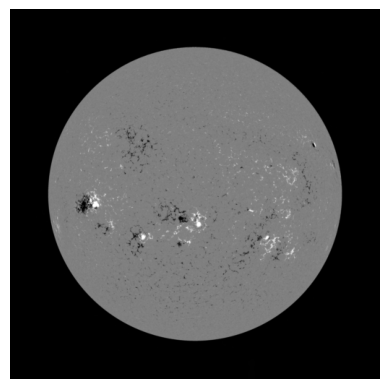

In [116]:
# Alternatively, display the image using matplotlib
image_original = np.load(original)
image_original = (image_original / image_original.max() * 255).astype(np.uint8)
plt.imshow(image_original, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/original_image.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


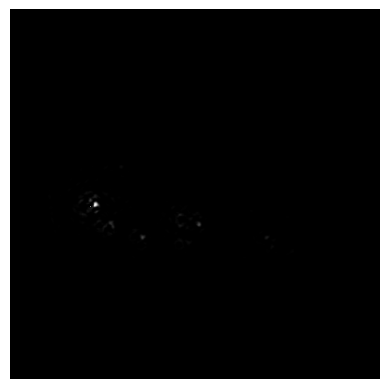

shapes: (512, 512), (512, 512)


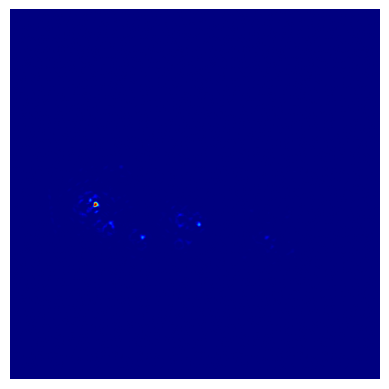

shapes: (512, 512), (512, 512)


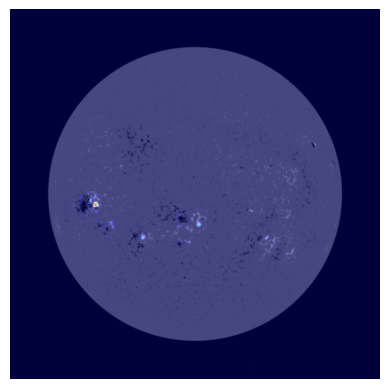

In [117]:
# Alternatively, display the image using matplotlib
image_guidedgradcam = np.load(guidedgradcam)
image_guidedgradcam = (image_guidedgradcam / image_guidedgradcam.max() * 255).astype(np.uint8)
plt.imshow(image_guidedgradcam, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/guidedgradcam_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

plt.imshow(superimpose_original(image_original, image_guidedgradcam,1), cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/guidedgradcam.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


image_superimpose = superimpose_original(np.load(original),np.load(guidedgradcam))
image_superimpose = (image_superimpose / image_superimpose.max() * 255).astype(np.uint8)
plt.imshow(image_superimpose, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/superimposed.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

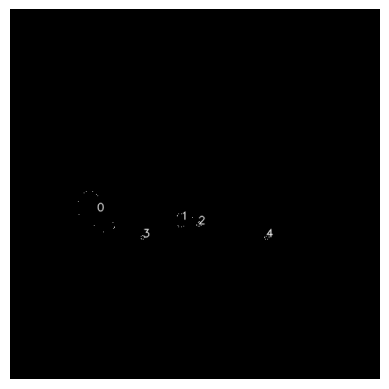

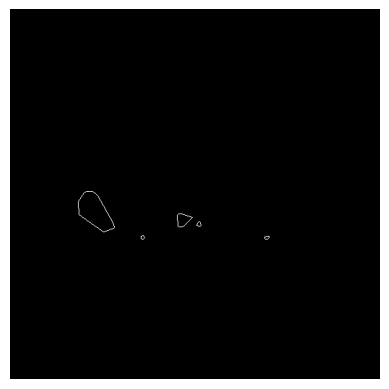

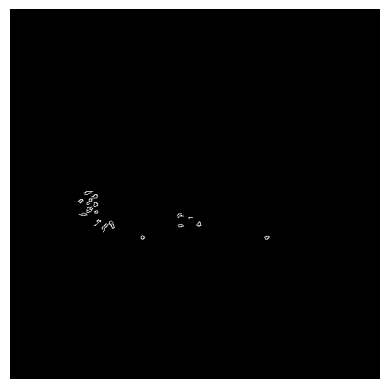

In [118]:
activation_hulls,img = get_hulls(guidedgradcam,original,lower_threshold=30,upper_threshold=50,min_samples=2,distance_threshold=10,numpy=True)

# import numpy as np
# import cv2 as cv
# import matplotlib.pyplot as plt

# Create a blank 512x512 single-channel image
image = np.zeros((512, 512), dtype=np.uint8)

# Set the points to white
for idx, point_set in activation_hulls:
    for point in point_set:
        image[point[1], point[0]] = 255  # Set pixel to white

    # Calculate the centroid of the cluster
    centroid = np.mean(point_set, axis=0).astype(int)
    
    # Add the cluster number at the centroid
    cv.putText(image, str(idx), tuple(centroid), cv.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1, cv.LINE_AA)

# Alternatively, display the image using matplotlib
image = (image / image.max() * 255).astype(np.uint8)
plt.imshow(image, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/cluster_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()



# Create a blank 512x512 single-channel image
image = np.zeros((512, 512), dtype=np.uint8)

# Set the points to white and draw lines across the hulls
for idx, point_set in activation_hulls:
    for point in point_set:
        image[point[1], point[0]] = 255  # Set pixel to white
    
    # Draw lines connecting the points in the convex hull
    for i in range(len(point_set)):
        start_point = tuple(point_set[i])
        end_point = tuple(point_set[(i + 1) % len(point_set)])  # Wrap around to the first point
        cv.line(image, start_point, end_point, 255, 1)

    # # Calculate the centroid of the cluster
    # centroid = np.mean(point_set, axis=0).astype(int)
    
    # # Add the cluster number at the centroid
    # cv.putText(image, str(idx), tuple(centroid), cv.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1, cv.LINE_AA)

# Alternatively, display the image using matplotlib
image = (image / image.max() * 255).astype(np.uint8)
plt.imshow(image, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/enclosed_cluster_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


# Alternatively, display the image using matplotlib
img = (img / img.max() * 255).astype(np.uint8)
plt.imshow(img, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/edge_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# # Alternatively, display the image using matplotlib
# plt.imshow(mask, cmap='gray')
# plt.title("Points Plot")
# plt.axis('off')  # Hide axes
# plt.show()

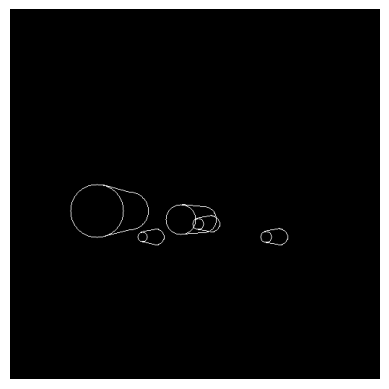

In [119]:
bouding_img = draw_bounding_region([x[1] for x in activation_hulls],nw_angle=-30, sw_angle=30, es_buffer=5, ws_buffer=20)
# Alternatively, display the image using matplotlib
bouding_img = (bouding_img / bouding_img.max() * 255).astype(np.uint8)
plt.imshow(bouding_img, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/bouding_region_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

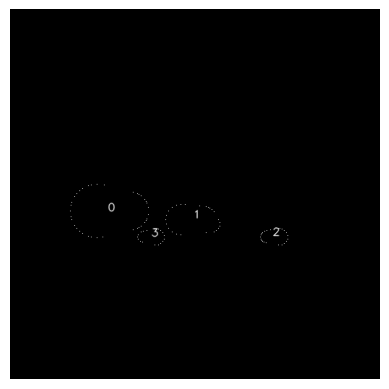

In [120]:

bounding_hulls_ = bounding_hulls(bouding_img,min_samples=2,distance_threshold=10)
# Create a blank 512x512 single-channel image
image = np.zeros((512, 512), dtype=np.uint8)

# Set the points to white
for idx, point_set in bounding_hulls_:
    for point in point_set:
        image[point[1], point[0]] = 255  # Set pixel to white

    # Calculate the centroid of the cluster
    centroid = np.mean(point_set, axis=0).astype(int)
    
    # Add the cluster number at the centroid
    cv.putText(image, str(idx), tuple(centroid), cv.FONT_HERSHEY_SIMPLEX, 0.5, 255, 1, cv.LINE_AA)

image = (image / image.max() * 255).astype(np.uint8)
plt.imshow(image, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/bouding_region_cluster_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [121]:
import post_hoc_explanation
ars = pd.read_csv('ars.csv')
ar_names, ar_lat, ar_lon = retrieve_ar(date_, plage=True, events=True, media=media)
print(ar_names)

pix_list = [post_hoc_explanation.convert_to_pix(float(x[1]), float(x[0])) for x in zip(ar_lat, ar_lon)]
flares = [item for item in list(zip(ar_names, pix_list))]

[12248, 12251, 12252, 12253]


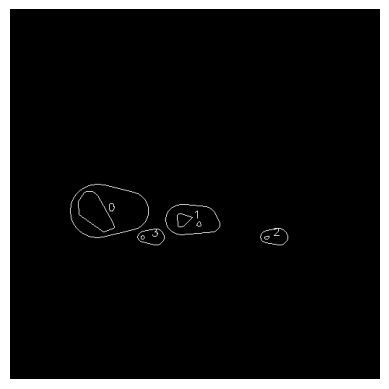

In [122]:
bounding_hulls_img = draw_hulls(bounding_hulls_, flares, activation_hulls=activation_hulls)
# Alternatively, display the image using matplotlib

bounding_hulls_img = (bounding_hulls_img / bounding_hulls_img.max() * 255).astype(np.uint8)
plt.imshow(bounding_hulls_img, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/final_bounding_region_cluster_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

Radius of the circular mask: 204.2508544921875


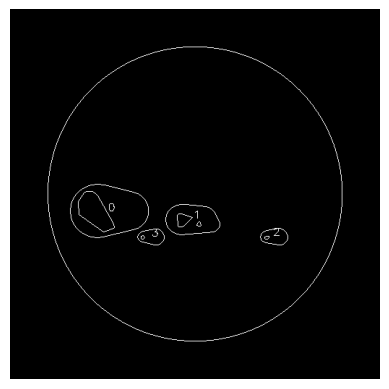

In [123]:
from post_hoc_analysis import superimpose_circular_edge_npy,annotate_points
superimposed = superimpose_circular_edge_npy(original, bounding_hulls_img)
superimposed = (superimposed / superimposed.max() * 255).astype(np.uint8)
plt.imshow(superimposed, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/circular_edge+cluster_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

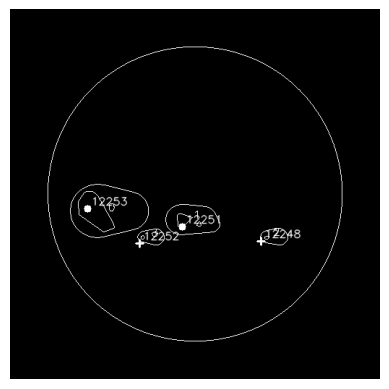

In [124]:
distances = flare_hull_distance_2(flares, bounding_hulls_)
distances_df = pd.DataFrame(distances, columns=["Flare", "Closest Hull", "Distance"])
annotated = annotate_points(distances_df, flares, superimposed)

annotated = (annotated / annotated.max() * 255).astype(np.uint8)
plt.imshow(annotated, cmap='gray')
# plt.title("Points Plot")
plt.axis('off')  # Hide axes
plt.savefig(r'imgs/annotated_grayscale.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [125]:
distances_df

,Flare,Closest Hull,Distance
0,12248,2,1.414214
1,12251,1,0.000000
2,12252,3,3.162278
3,12253,0,0.000000
